# Supplemental Material

Kendra Wyant  
March 5, 2026

This file contains the supplemental materials for *Dynamic lapse risk prediction in a national sample of individuals with opioid use disorder using personal sensing and machine learning*. It includes all supplemental figures and tables.

In [ ]:
#| include: false
#| message: false
#| warning: false

library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

── Attaching packages ────────────────────────────────────── tidymodels 1.2.0 ──
✔ broom        1.0.7      ✔ rsample      1.2.1 
✔ dials        1.2.1      ✔ tune         1.2.1 
✔ infer        1.0.7      ✔ workflows    1.1.4 
✔ modeldata    1.3.0      ✔ workflowsets 1.1.0 
✔ parsnip      1.2.1      ✔ yardstick    1.3.1 
✔ recipes      1.0.10     
── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()
• Learn how to get started at https://www.tidymodels.org/start/


Attaching package: 'kableExtra'

The following object is masked from 'package:dplyr':

    group_rows

ℹ SHA-1 hash of file is "0faa14c0c44c2635216370888b7da9bfa8d07979"

## Protocol Deviations

We published this study’s protocol as a registered report (International Registered Report Identifier \[IRRID\]: DERR1-10.2196/29563) during the initial enrollment of pilot participants. The registered report can be found at <https://www.researchprotocols.org/2021/12/e29563/>. For transparency, we documented changes made to the registered report below:

### Sensing Data Streams

Our candidate models included features derived from a subset of intake self-report measures, daily surveys, and geolocation sensing data (see Measures section). Consequently, we excluded cellular communication data, daily video check-ins, app usage data, and certain self-report measures. These decisions were informed by (1) our group’s personal sensing work with alcohol use disorder, (2) technological constraints, and (3) the desire to balance feature diversity for capturing lapse complexity and minimizing participant burden and computational cost.

1.  In our alcohol use disorder research, daily surveys and geolocation sensing have shown moderate to excellent predictive signal (aurocs .72-.91<!--confirm claire auroc-->) \[@wyantMachineLearningModels2024; @wyantForecastingRiskAlcoholunderreview\<!--Cite claire gps paper--\>\]. Cellular communication sensing, however, has fallen short of these thresholds (.68 auROC<!--cite meta paper-->). Moreover, Apple places strict restrictions on app access to communications, meaning inclusion of these features would result in a model that could only be deployed within an Android operating system.

2.  We discontinued collecting daily video check-ins about 6 months into the 2.5 year data collection due to technical issues and App usage data (beyond the required study tasks) were generally sparse and inconsistent across participants.

3.  Self-report measures can substantially increase data collection burden and expand the feature space. Therefore, we opted to generally not include self-report measures. Intake and monthly surveys were lengthy (20–30 minutes) and, based on our work with alcohol use disorder, added no incremental predictive value beyond the dynamic sensing data. However, we did include a subset of key demographic variables reported at intake (gender, race/ethnicity, income, sexual orientation, and geographic location). We selected these variables based on evidence of influencing OUD treatment access and clinical outcomes or carrying general societal stigma to reduce model bias by preventing these effects being encoded into the model indirectly by proxy variables.

### Resampling Method

Our initial protocol proposed repeated cross-validation for model selection and a single held-out test set for evaluation. Although we nearly reached our recruitment goal (N = 451/480), the number of participants with usable data was substantially lower (N = 299). To maximize data use, we used nested cross-validation (6 repeats of 5-fold cross-validation on the outer loop and 2 repeats of 5-fold cross-validation on the inner loop). This resampling method still removes optimization bias by separating model selection and evaluation. Specifically, nested cross-validation embeds an inner cross-validation loop for model selection within an outer cross-validation loop for model evaluation. This approach makes more efficient use of data in that each observation contributes to model training and model evaluation during the cross-validation process. Moreover, final estimates are averaged over 30 test sets leading to less variance in the estimate compared to a single test set.

## Daily Survey

This survey asks about your recent drug use, medication assisted treatment, mood, and daily experiences. Several questions ask about using drugs “for non-medical reasons” which means using drugs to feel intoxicated or high. It is possible to use a drug you are prescribed for non-medical reasons, for example, by taking more than prescribed.

1.  Have you used any opioids for non-medical reasons that you have not yet reported?

    -   No
    -   Yes

    Please select the time(s) that you have not yet reported when you used opioids for non-medical reasons: \[Display if Q1 is Yes\]

    \[TIME PICKER, MULTI-SELECT\]

Thinking about the past 24 hours…

1.  Which of these drugs have you used for non-medical reasons? Select all that apply.

    -   Alcohol
    -   Cannabis (marijuana, pot, grass, hash, K2, spice, etc.)
    -   Stimulants (cocaine, meth, speed, ecstasy, molly, Adderall, etc.)
    -   Inhalants (nitrous, glue, petrol, paint thinner, etc.)
    -   Sedatives or sleeping pills (Valium, Serepax, Rohypnol, etc.)
    -   Hallucinogens (LSD, acid, mushrooms, PCP, special K, etc.)
    -   None of the above

2.  Did you take your daily medication for opioid use (e.g., Suboxone, Methadone, Buprenorphine, etc.). as prescribed?

    -   Yes
    -   No, I missed a dose
    -   No, I am using a monthly medication (e.g., Vivitrol)
    -   No, I am no longer prescribed medication for opioid use

Thinking about the past 24 hours…

1.  Think about the worst pain you experienced. How painful was it?

    -   No pain
    -   Mildly
    -   Moderately
    -   Considerably
    -   Extremely

2.  Think about the greatest urge you had to use opioids. How strong was it?

    -   No urge
    -   Mildly
    -   Moderately
    -   Considerably
    -   Extremely

3.  Think about the riskiest situation you experienced (people, places, or things that interfere with your recovery). How risky was it?

    -   No risky situation
    -   Mildly
    -   Moderately
    -   Considerably
    -   Extremely

4.  Think of the biggest hassle or most stressful event you experienced. How stressful was it?

    -   No hassle/stressful event
    -   Mildly
    -   Moderately
    -   Considerably
    -   Extremely

5.  Think of the most pleasant or positive event you experienced. How pleasant was it?

    -   No pleasant/positive event
    -   Mildly
    -   Moderately
    -   Considerably
    -   Extremely

Thinking about the past 24 hours…

1.  How did you sleep?

    -   Very badly
    -   Badly
    -   Neutral
    -   Well
    -   Very well

2.  How depressed have you felt?

    -   Not at all
    -   Mildly
    -   Moderately
    -   Considerably
    -   Extremely

3.  How angry have you felt?

    -   Not at all
    -   Mildly
    -   Moderately
    -   Considerably
    -   Extremely

4.  How anxious have you felt?

    -   Not at all
    -   Mildly
    -   Moderately
    -   Considerably
    -   Extremely

5.  How relaxed have you felt?

    -   Not at all
    -   Mildly
    -   Moderately
    -   Considerably
    -   Extremely

6.  How happy have you felt?

    -   Not at all
    -   Mildly
    -   Moderately
    -   Considerably
    -   Extremely

Now thinking forward to the next week…

1.  How motivated are you to completely avoid using opioids for non-medical reasons?

    -   Not at all
    -   Mildly
    -   Moderately
    -   Considerably
    -   Extremely

2.  How confident are you in your ability to completely avoid using opioids for non-medical reasons?

    -   Not at all
    -   Mildly
    -   Moderately
    -   Considerably
    -   Extremely

Thank you! You have now completed the daily update.

## Monthly Geolocation Context Questions

The next questions ask you about the places you have gone more than once or spent the night at in the past month.

Our automated system has identified these places using the data you share with us. The system is not perfect; it may have identified places that you have not been. You will be able to tell us if the system has made an error.

You visited the place shown below, near \[*address*\], several times in the past month. Recently, you visited this place on \[*date*\].

\[display on map\]

1.  Which of the following best describes this place?

    -   My home \[If selected, skip to end of survey\]
    -   Someone else’s home
    -   A shelter, group home, hotel, or other temporary place I stayed \[If selected, skip to end of survey\]
    -   A restaurant, business, public place, or other non-residential place  
    -   I do not recognize this location or was just passing by \[If selected, skip to end of survey\]

2.  What do you do at this place? Select all that apply.

    – Work – Take classes – Religious or spiritual activities – Volunteer or do community service – Exercise or play sports – Spend time with friends – Spend time with family – Socialize with new people – Relax – Drink alcohol – Get mental health care (e.g., counseling, talk therapy, group therapy, support group)

    -   Get medication for opioid treatment (e.g., Suboxone, Methadone, etc.) – Get physical health care – None of the above

3.  In general, how often is going to this place pleasant?

    -   Never
    -   Rarely
    -   Sometimes
    -   Most of the time
    -   Always

4.  In general, how often is going to this place unpleasant?

    -   Never
    -   Rarely
    -   Sometimes
    -   Most of the time
    -   Always

5.  In general, how much does going to this place help your recovery from opioids?

    -   Not at all
    -   Mildly
    -   Moderately
    -   Considerably
    -   Extremely

6.  In general, how much does going to this place harm your recovery from opioids?

    -   Not at all
    -   Mildly
    -   Moderately
    -   Considerably
    -   Extremely

## Supplemental Figures

### Figure S1: Global Feature Importance for all Feature Categories

In [ ]:
#| code-fold: true

shap_levels_all <- shaps |> 
  group_by(variable_grp) |>
  summarize(mean_value = mean(abs(value)), .groups = "drop") |>
  arrange(mean_value) |> 
  pull(variable_grp)

n_obs <- max(shaps$id_obs)

shaps_day_max <- shaps |>
  group_by(id_obs) |>
  slice_max(value) |> 
  group_by(variable_grp) |> 
  summarise(n = n(),
            prop = n/n_obs) |> 
  ungroup() 


global_panel_all <- shaps |>
  group_by(variable_grp) |>
  summarize(mean_value = mean(abs(value)), .groups = "drop") |> 
  mutate(variable_grp = factor(variable_grp, levels = shap_levels_all)) |> 
  ggplot(mapping = aes(x = variable_grp, y = mean_value)) +
  geom_bar(fill = "#240e31", 
           stat = "identity", position = "dodge") +
  labs(y = "Mean(|Shapley Value|)",
       x = NULL,
       fill = NULL) +
  theme_classic() +
  theme(axis.text=element_text(size=9.5),
        legend.key.size = unit(0.25, "cm"),
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
        legend.position = "right") +
  coord_flip()


local_panel_all <- shaps_day_max |> 
  right_join(shaps |> ungroup() |> select(variable_grp) |> distinct(), 
             by = "variable_grp") |> 
  mutate(prop = if_else(is.na(prop), 0, prop)) |> 
  mutate(variable_grp = factor(variable_grp, levels = shap_levels_all)) |>
  ggplot(mapping = aes(x = variable_grp, y = prop)) +
  geom_bar(fill = "#046B52", 
           stat = "identity", position = "dodge") +
  labs(y = "Proportion of days as top feature",
       x = NULL,
       fill = NULL) +
  theme_classic() +
  theme(axis.text=element_text(size=9.5),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        legend.key.size = unit(0.25, "cm"),
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
        legend.position = "right") +
  coord_flip()

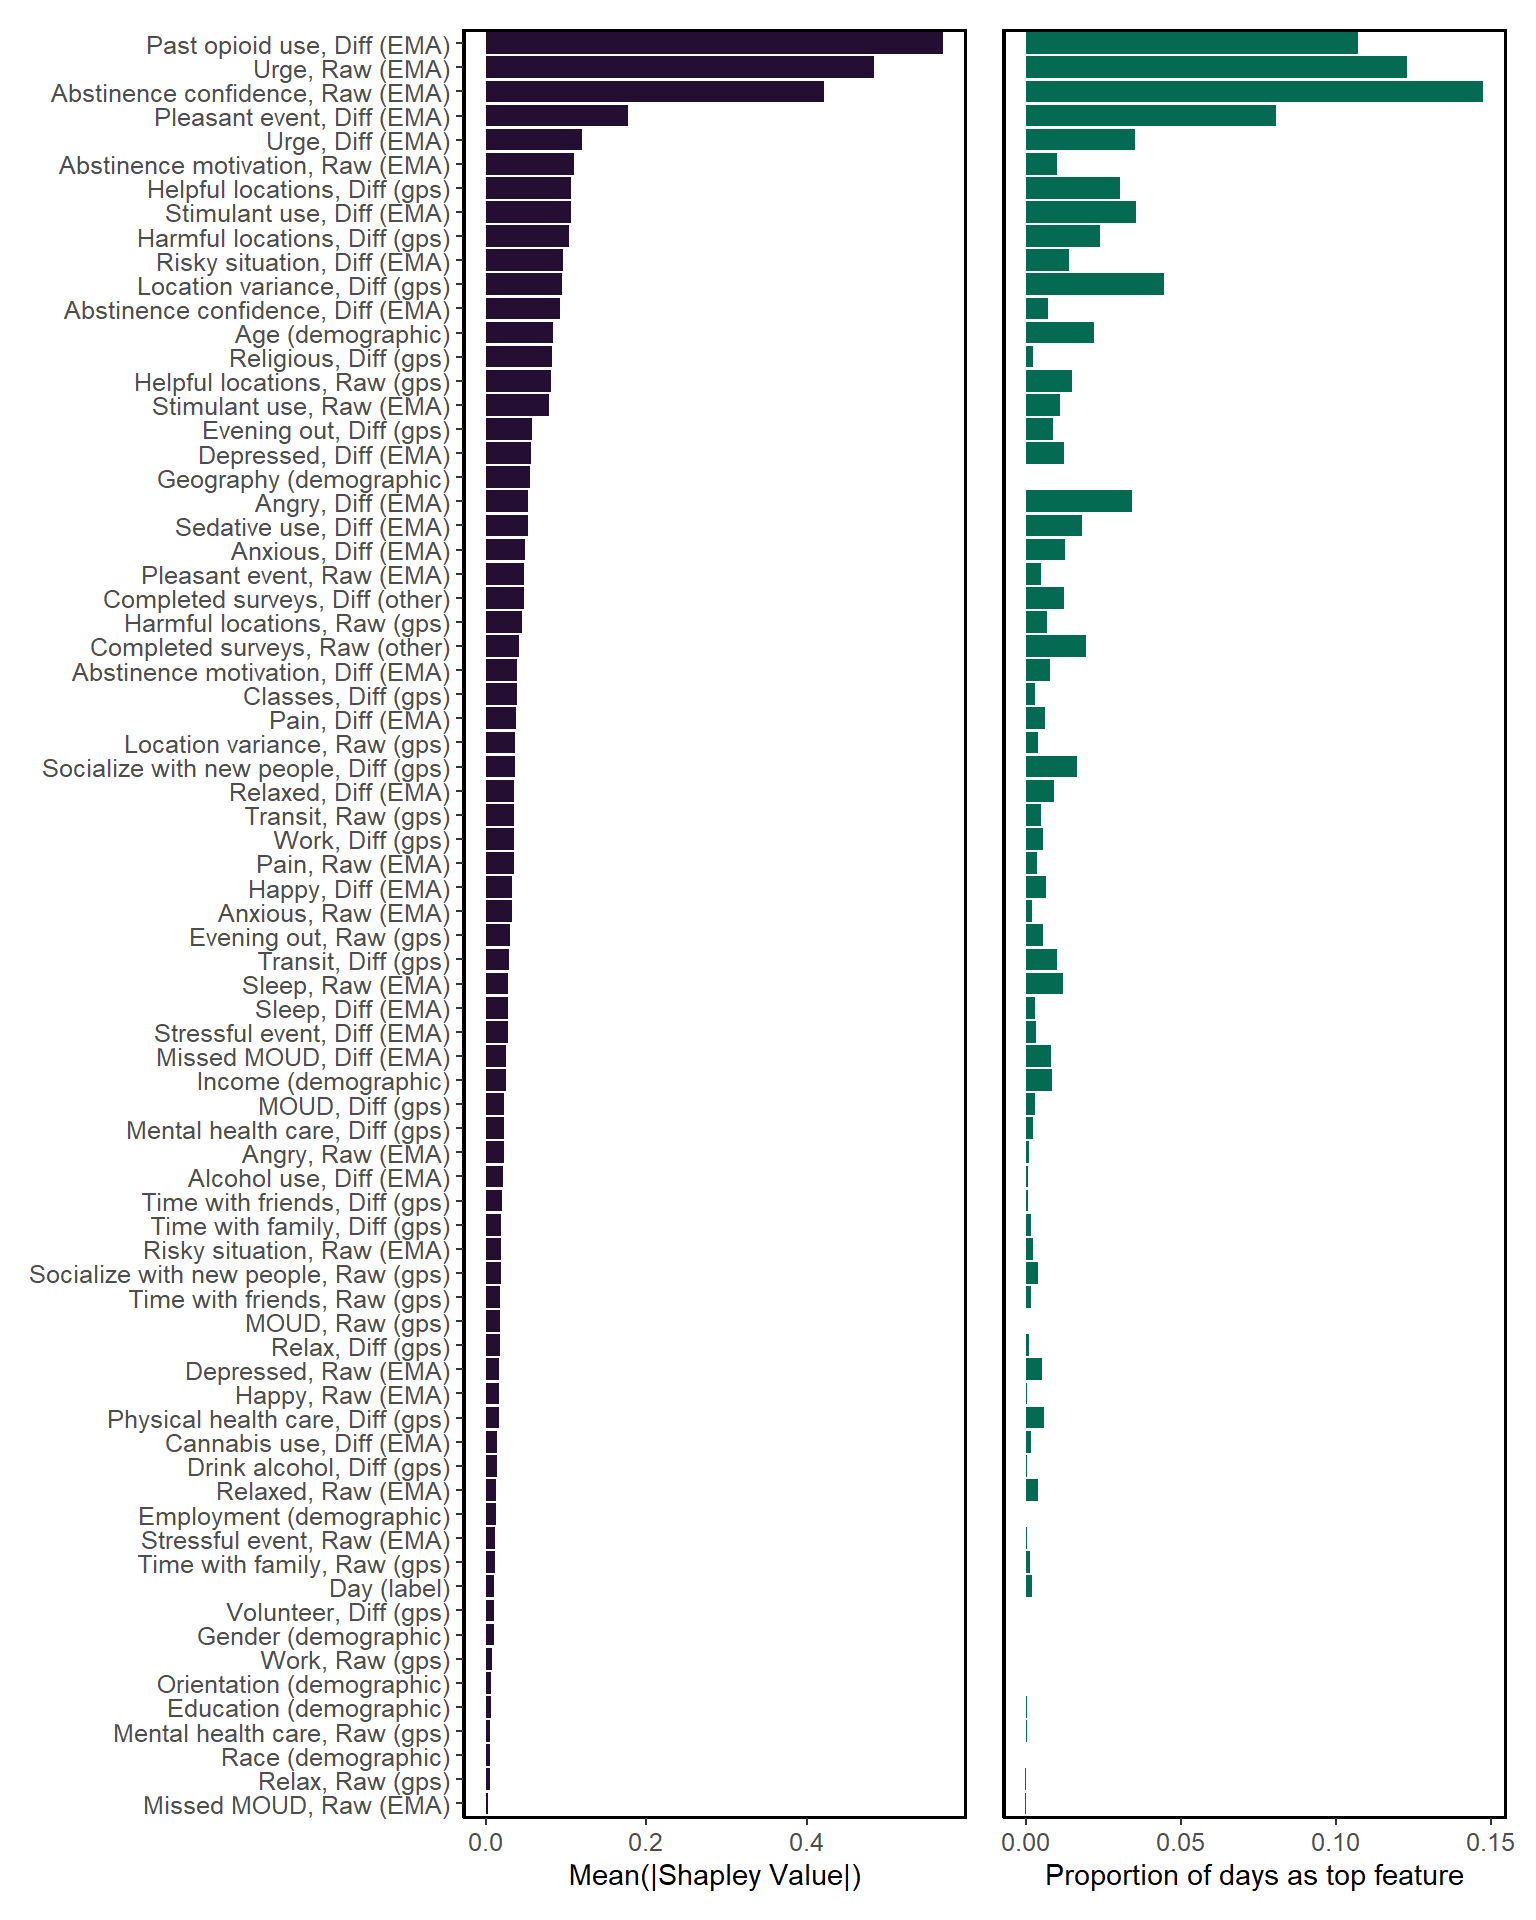

In [ ]:
#| echo: false
#| fig-width: 8
#| fig-height: 10

global_panel_all + local_panel_all

## Supplemental Tables

### Table S1: Simple k-fold Performance by Statistical Algorithm

We used 6 repeats of 5-fold cross-validation for preliminary testing. We report the median auroc for the best model configuration for each candidate statistical algorithm below.

In [ ]:
metrics_avg <- kfold_results |> 
  group_by(algorithm, feature_set, hp1, hp2, hp3, resample) |>  
   summarize(roc_auc = median(roc_auc),
             n_jobs = n(), .groups = "drop") |> 
  relocate(n_jobs) |>  
  arrange(desc(roc_auc)) |> 
  ungroup()

metrics_avg |> 
  group_by(algorithm) |> 
  slice(1) |> 
  mutate(roc_auc = round(roc_auc, 3)) |> 
  select(Algorithm = algorithm,
         `Median auROC` = roc_auc) |> 
  arrange(desc(`Median auROC`)) |> 
  kbl() |> 
  kable_classic()

Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
Use 'xfun::attr2()' instead.
See help("Deprecated")

### Table S2: Demographic Contrasts for all Models

In [ ]:
#| label: tbl-fairness
#| tbl-cap: "Median difference in auROC, 95% Bayesian credible interval (CI), and posterior probability that that the auROC difference was smaller or larger than 0 for fairness contrasts."
#| code-fold: true

footnote_table <- "Median auROC differences less than 0 indicate the model, on average, performed worse for the disadvantaged group (not male, non-White and/or Hispanic, income below poverty line, small town/rural, not heterosexual) compared to the advantaged group (male, non-Hispanic White, income above poverty line, urban/suburban, heterosexual). Bayesian CI represents the range of values where there is a 95% probability that the true auROC difference lies within that range. Probability indicates the posterior probability that this difference is smaller or larger than 0 (i.e., the models are performing differently for fairness subgroups)."


pp_sex <- pp_dem |> 
  filter(contrast == "not male vs male") |> 
   mutate(ci = str_c("[", round(lower, 3), ", ", round(upper, 3), "]"),
         median = as.character(round(median, 3)),
         probability = as.character(round(probability, 3))) |> 
  select(contrast, median, ci, probability) |> 
  rename(Median = median,
         `Bayesian CI` = ci,
         Probability = probability)

pp_income <- pp_dem |> 
  filter(contrast == "below poverty vs above poverty") |> 
   mutate(ci = str_c("[", round(lower, 3), ", ", round(upper, 3), "]"),
         median = as.character(round(median, 3)),
         probability = as.character(1 - round(probability, 3))) |> 
  select(contrast,median, ci, probability) |> 
  rename(`Median` = median,
         `Bayesian CI` = ci,
         `Probability` = probability)

pp_race <- pp_dem |> 
  filter(contrast == "Hispanic and/or not white vs non-Hispanic White") |> 
  mutate(contrast = "Hispanic and/or not White vs non-Hispanic White") |> 
   mutate(ci = str_c("[", round(lower, 3), ", ", round(upper, 3), "]"),
         median = as.character(round(median, 3)),
         probability = as.character(sprintf("%.3f", probability))) |> 
  select(contrast, median, ci, probability) |> 
  rename(`Median` = median,
         `Bayesian CI` = ci,
         `Probability` = probability)

pp_geography <- pp_dem |> 
  filter(contrast == "small town/rural vs urban/suburban") |> 
  mutate(ci = str_c("[", round(lower, 3), ", ", round(upper, 3), "]"),
         median = as.character(round(median, 3)),
         probability = as.character(sprintf("%.3f", probability))) |> 
  select(contrast, median, ci, probability) |> 
  rename(`Median` = median,
         `Bayesian CI` = ci,
         `Probability` = probability)

pp_orientation <- pp_dem |> 
  filter(contrast == "not heterosexual vs heterosexual") |> 
  mutate(ci = str_c("[", round(lower, 3), ", ", round(upper, 3), "]"),
         median = as.character(round(median, 3)),
         probability = as.character(sprintf("%.3f", probability))) |> 
  select(contrast, median, ci, probability) |> 
  rename(`Median` = median,
         `Bayesian CI` = ci,
         `Probability` = probability)



pp_sex |> 
  bind_rows(pp_income) |> 
  bind_rows(pp_race) |> 
  bind_rows(pp_orientation) |> 
   bind_rows(pp_geography) |> 
  kbl() |> 
  kable_classic() |> 
  kableExtra::add_footnote(label = footnote_table,
                           notation = "none",
                           escape = FALSE)

Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
Use 'xfun::attr2()' instead.
See help("Deprecated")